In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train,Y_train), (X_test,Y_test)=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


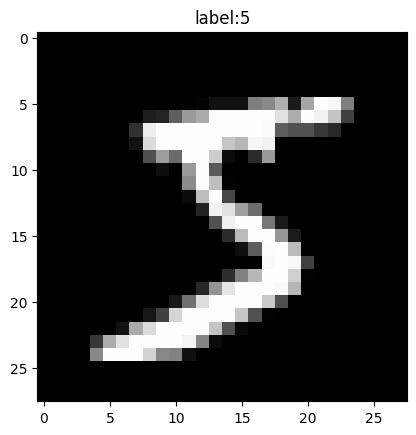

In [5]:
plt.imshow(X_train[0],cmap='gray')
plt.title(f"label:{Y_train[0]}")
plt.show()

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

In [18]:
from tensorflow.keras import Input
model = models.Sequential([
    Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [21]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [24]:
model.fit(X_train,Y_train,epochs=5,validation_data=(X_test,Y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.6574 - loss: 0.9883 - val_accuracy: 0.8931 - val_loss: 0.3576
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9055 - loss: 0.3115 - val_accuracy: 0.9273 - val_loss: 0.2387
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9330 - loss: 0.2182 - val_accuracy: 0.9459 - val_loss: 0.1779
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9477 - loss: 0.1689 - val_accuracy: 0.9580 - val_loss: 0.1341
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9572 - loss: 0.1411 - val_accuracy: 0.9674 - val_loss: 0.1091


In [25]:
test_loss,test_accuracy=model.evaluate(X_test,Y_test)
print('Test accuracy:',test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9674 - loss: 0.1091
Test accuracy: 0.9674000144004822


In [26]:
prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [27]:
predicted_digit=np.argmax(prediction[0])

In [29]:
print("Predicted digit:",predicted_digit)
print("Actual Digit:",Y_test[0])

Predicted digit: 7
Actual Digit: 7


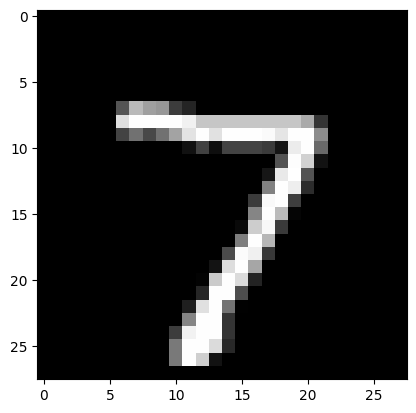

In [30]:
plt.imshow(X_test[0].reshape(28,28),cmap='gray')
plt.show()